# EARLI: Evolutionary Algorithm with RL Initialization
# Inference usage example

## Setup

### Install

Run the following steps **only if EARLI is not yet installed in your machine** (e.g., no need to install if you use EARLI's docker).

In [ ]:
# Verify Python>=3.10
import sys
print(sys.version)

In [ ]:
# Verify GPU is available
!nvidia-smi

In [4]:
# Install build tools for compiling C/C++ extensions.
# If you have root on this notebook (e.g. in Google Colab): uncomment.
# Otherwise: install this outside the notebook.
!apt-get update -y && apt-get install -y git build-essential ninja-build

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [345 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,532 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,623 kB]
G

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd '/content/drive/MyDrive/EARLI-main'

/content/drive/MyDrive/EARLI-main


In [5]:
!pip install --upgrade --extra-index-url https://pypi.nvidia.com -c constraints.txt .

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
Processing /content/drive/MyDrive/EARLI-main
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://gitlab.com/igreenberg/initializable_hgs.git to /tmp/pip-install-1ssg3vuy/hygese_3dc46c8308a24c4d84b04dba17f96dd4
  Running command git clone --filter=blob:none --quiet https://gitlab.com/igreenberg/initializable_hgs.git /tmp/pip-install-1ssg3vuy/hygese_3dc46c8308a24c4d84b04dba17f96dd4
  Resolved https://gitlab.com/igreenberg/initializable_hgs.git to commit 861042ecdb0d0d992f6f063252aac78a9af1abd5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Import

In [6]:
import pickle as pkl
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from earli.utils import analysis_utils as utils
from earli import download_data, main, test_injection

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

### Download data

Download test dataset of VRP instances in Sao Paulo and Rio, based on the [Olist benchmark](https://github.com/NVlabs/olist-vrp-benchmark).

In [7]:
download_data.main(['--cleanup', '--force'])

problem_instances.zip: 100%|██████████| 911M/911M [00:55<00:00, 17.1MB/s]


Successfully downloaded to datasets/problem_instances.zip
Extracting datasets/problem_instances.zip to datasets
Successfully extracted to datasets

Extracted contents in datasets/problem_instances:
  vrp-test-size-100-rio-n_problems-256.pkl (10.4 MB)
  vrp-test-size-100-sp-n_problems-256.pkl (10.4 MB)
  vrp-test-size-20-rio-n_problems-256.pkl (0.9 MB)
  vrp-test-size-20-sp-n_problems-256.pkl (0.9 MB)
  vrp-test-size-200-rio-n_problems-256.pkl (40.2 MB)
  vrp-test-size-200-sp-n_problems-256.pkl (40.2 MB)
  vrp-test-size-30-rio-n_problems-256.pkl (1.9 MB)
  vrp-test-size-30-sp-n_problems-256.pkl (1.9 MB)
  vrp-test-size-300-rio-n_problems-256.pkl (89.7 MB)
  vrp-test-size-300-sp-n_problems-256.pkl (89.7 MB)
  vrp-test-size-400-rio-n_problems-256.pkl (158.6 MB)
  vrp-test-size-400-sp-n_problems-256.pkl (158.6 MB)
  vrp-test-size-50-rio-n_problems-256.pkl (2.7 MB)
  vrp-test-size-50-sp-n_problems-256.pkl (2.7 MB)
  vrp-test-size-500-rio-n_problems-256.pkl (247.1 MB)
  vrp-test-size-500-sp-

In [8]:
ls -lh datasets/problem_instances/vrp-test-size-100-sp-n_problems-256.pkl

-rw------- 1 root root 11M Dec 12 14:03 datasets/problem_instances/vrp-test-size-100-sp-n_problems-256.pkl


## Run RL initialization

Run the RL agent with the arguments specified in `config.yaml`.

Key arguments:
* `data_file`: Pickle file that containst the problem instances (e.g., one of the files downloaded above).
* `problem_range`: Which problem instances to solve (range of indices, e.g., \[0,16\] for the first 16 instances).
* `pretrained_fname`: Path of pretrained model to be used. We provide several compatible models under `pretrained_models/`.
* `n_beams`: Number of solutions to generate per instance.
* `n_parallel_problems`: Number of solutions to be generated in parallel. Larger is faster but consumes more GPU memory. **Reduce this in case of out-of-memory error**.

In [9]:
main.main()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
/usr/local/lib/python3.12/dist-packages/notebook/utils.py:280: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  return LooseVersion(v) >= LooseVersion(check)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Applying RL solver to 256 problem instances...
test time part 1/1: 0:00:26

Local-search duration per problem (for 8 solutions): 0.014646893367171288 +- 0.00025630897739870284 [s]
-------------------------------------
| test/                  |          |
|    mean_game_clocktime | 0.105    |
|    mean_game_iters     | 108      |
|    mean_reward         | -2.29    |
|    std_reward          | 0.278    |
|    total_games         | 256      |
-------------------------------------
Saving logs to: ./outputs/test_logs.pkl


## Run solver

Run the cuOpt solver with the arguments specified in `config_initialization.yaml`.

Key arguments:
* `methods`: Initialization methods to run (default / EARLI).
* `problems`: Same as `data_file` above.
* `solutions`: The RL solutions file (printed in the RL output under `Saving logs to`). Set to `null` if no solutions are available.
* `problem_range`: Which problem instances to solve (range of indices, e.g., \[0,16\] for the first 16 instances).
* `runtimes`: Solver runtimes to be tested. Should not be lower than `rl_runtime`.
* `rl_runtime`: RL runtime to be reduced from the solver time. Should be set to the mean runtime of the RL agent (printed in the RL output as `mean_game_clocktime`). The default falls back to the timings on our experiments, e.g., 0.767s for 500 customers.

In [10]:
%%time
test_injection.main()


injection
CuOpt version: 25.08.00
Problems: datasets/problem_instances/vrp-test-size-100-sp-n_problems-256.pkl
Solutions: ['outputs/test_logs.pkl']
Problems: 0-255

SOLVER_RUNTIME = 0.016:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Finished problem 1.001.1/5.256.2.
Finished problem 1.001.2/5.256.2.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Finished problem 1.002.1/5.256.2.
Finished problem 1.002.2/5.256.2.


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/content/drive/MyDrive/EARLI-main/earli/test_injection.py:397: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rr = rr.groupby(['method', 'total_runtime']).apply(lambda d: is_valid_method(d)).reset_index(drop=True)


Finished problem 5.256.2/5.256.2.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saving results to ./outputs/test_summary_injection.pkl
        method  total_runtime  init_runtime  problem_id  vehicles  \
0        cuOpt          0.016         0.000           0      11.0   
1     cuOpt_RL          0.016         0.016           0      11.0   
2        cuOpt          0.016         0.000           1       9.0   
3     cuOpt_RL          0.016         0.016           1       9.0   
4        cuOpt          0.016         0.000           2      11.0   
...        ...            ...           ...         ...       ...   
2555  cuOpt_RL          1.000         0.016         253      12.0   
2556     cuOpt          1.000         0.000         254       8.0   
2557  cuOpt_RL          1.000         0.016         254       8.0   
2558     cuOpt          1.000         0.000         255       8.0   
2559  cuOpt_RL          1.000         0.016         255       8.0   

              cost  attempted_injections  accepted  rejected  unconsidered  \
0     99199.499929                    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/content/drive/MyDrive/EARLI-main/earli/test_injection.py:449: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(rf.groupby(['total_runtime']).apply(lambda r: print_pairwise_comparison(
/content/drive/MyDrive/EARLI-main/earli/test_injection.py:453: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 

The output above presents the solution costs with and without RL initialization, and the difference between them, for every time-budget.

## Plot results

Read solver stats:

In [13]:
fpath = r'outputs/test_summary_injection.pkl'
with open(fpath, 'rb') as hh:
    dd = pkl.load(hh)
rr, info = dd['summary'], dd['info']

methods_map = dict(cuOpt='cuOpt', cuOpt_RL='EARLI')
rr, _ = utils.injection_post_process(rr, None, methods_map, baseline='cuOpt')

rr

/content/drive/MyDrive/EARLI-main/earli/utils/analysis_utils.py:876: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rr = rr.groupby(['total_runtime','problem_id'], group_keys=False).apply(foo)
/content/drive/MyDrive/EARLI-main/earli/utils/analysis_utils.py:894: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.77642616 -2.26411332 -1.02972499 ...  0.63210386  2.27796883
 -0.07446961]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rr.loc[rr.method == method, f'{ycol}_vs_{baseline}_ratio [%]'] = 100 * (
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: De

,method,total_runtime,init_runtime,problem_id,vehicles,cost,attempted_injections,accepted,rejected,unconsidered,...,method0,best_vehicles,vehicles_suboptimality_diff [%],vehicles_suboptimality_ratio [%],vehicles_vs_cuOpt_ratio [%],best_cost,cost_suboptimality_diff [%],cost_suboptimality_ratio [%],cost_vs_cuOpt_ratio [%],n_accepted
0,cuOpt,0.016,0.000,0,11.0,99199.499929,0,0,0,0,...,cuOpt,11.0,0.0,0.0,0.0,95902.699500,3.610599,3.437651,0.000000,0
1,EARLI,0.016,0.016,0,11.0,98429.289062,0,0,0,0,...,cuOpt_RL,11.0,0.0,0.0,0.0,95902.699500,2.767077,2.634534,-0.776426,0
2,cuOpt,0.016,0.000,1,9.0,89469.599366,0,0,0,0,...,cuOpt,9.0,0.0,0.0,0.0,83508.899848,6.528056,7.137802,0.000000,0
3,EARLI,0.016,0.016,1,9.0,87443.906250,0,0,0,0,...,cuOpt_RL,9.0,0.0,0.0,0.0,83508.899848,4.309551,4.712080,-2.264113,0
4,cuOpt,0.016,0.000,2,11.0,86529.200301,0,0,0,0,...,cuOpt,11.0,0.0,0.0,0.0,83923.400203,2.853827,3.104974,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,EARLI,1.000,0.016,253,12.0,90554.000771,8,2,6,0,...,cuOpt_RL,12.0,0.0,0.0,0.0,89985.200846,0.622940,0.632104,0.632104,2
2556,cuOpt,1.000,0.000,254,8.0,83850.999875,0,0,0,0,...,cuOpt,8.0,0.0,0.0,0.0,83850.999875,0.000000,0.000000,0.000000,0
2557,EARLI,1.000,0.016,254,8.0,85761.099515,8,6,2,0,...,cuOpt_RL,8.0,0.0,0.0,0.0,83850.999875,2.091908,2.277969,2.277969,5+
2558,cuOpt,1.000,0.000,255,8.0,99637.300678,0,0,0,0,...,cuOpt,8.0,0.0,0.0,0.0,99456.200682,0.198338,0.182090,0.000000,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Plot the ratio of instances where the solver found a feasible solution:

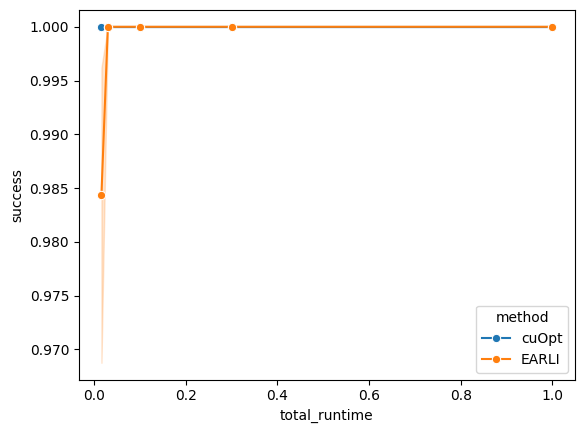

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
sns.lineplot(data=rr, x='total_runtime', hue='method', y='success', marker='o');

Plot cost gaps: how far was the solver cost from the best known cost, on average over instances?

/content/drive/MyDrive/EARLI-main/earli/utils/analysis_utils.py:836: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return r.groupby(list(group_cols), group_keys=False).apply(add_col)


Removing 8 problems with suboptimal vehicles (0.3%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


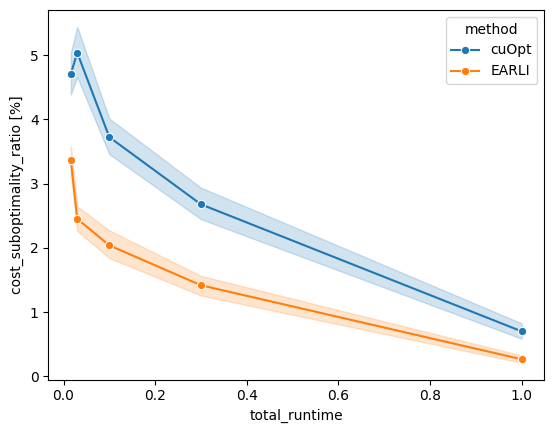

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# remove instances in which some of the solvers did not find a feasible solution (since these instances may unfairly bias the cost evaluation).
rr = utils.add_col_all_success(rr)
n_removed = (~rr.all_success).sum()
print(f'Removing {n_removed:d} problems with suboptimal vehicles ({100*n_removed/len(rr):.1f}%)')
rr = rr[rr.all_success]

sns.lineplot(data=rr, x='total_runtime', hue='method', y='cost_suboptimality_ratio [%]', marker='o');

## Visualize solutions

In [16]:
method0 = 'cuOpt'
method1 = 'cuOpt_RL'
methods_map = dict(cuOpt='cuOpt', cuOpt_RL='EARLI')
problem_id = 0
runtime = 0.3  # [s]
area = 'sao_paulo'  # None / 'rio' / 'sao_paulo'

In [17]:
def extract_solution(info, runtime, problem_id, method):
    method_lab = method.replace('+', '_')
    key = f'time_{int(np.round(runtime))}_problem_{problem_id}_{method_lab}_iter_0'
    if key not in info['solutions']:
        print(key)
        raise Exception(f'Solution {key} was not found.')
    return info['solutions'][key]

# extract solutions
sol0 = extract_solution(info, runtime, problem_id, method0)
sol1 = extract_solution(info, runtime, problem_id, method1)

# extract problem instances
with open(info['config']['paths']['problems'], 'rb') as hh:
    problems = pkl.load(hh)

/usr/local/lib/python3.12/dist-packages/pyproj/transformer.py:816: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return self._transformer._transform_point(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pyproj/transformer.py:816: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return self._transformer._transform_point(
/usr/local/li

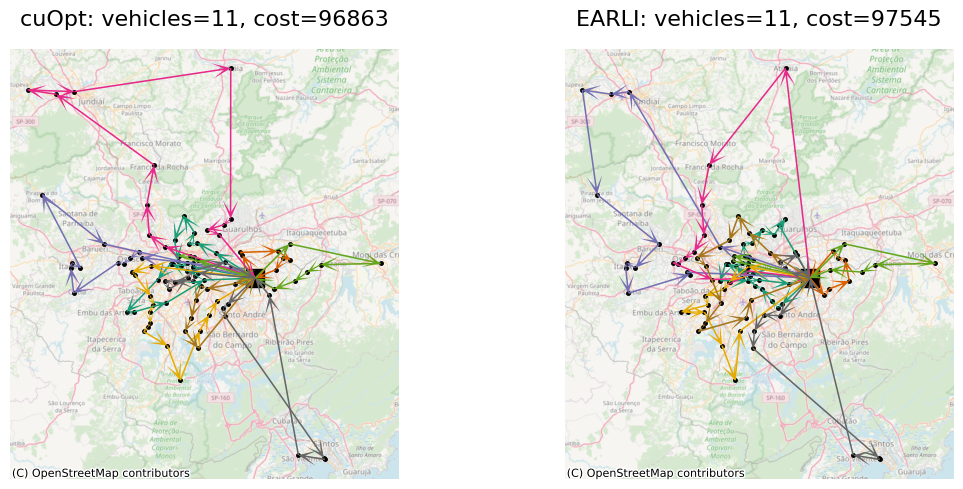

In [18]:
utils.display_solutions(rr, sol0, sol1, problems, problem_id, method0, method1, runtime, methods_map, area);